## Title: "Chapter 5-6 HW"
### Author: "Makenna Worley"
### Date: "10/28/2025"

In [55]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [56]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn

### Setup

In [57]:
default = pd.read_csv('Default.csv', na_values='?').dropna()
default['default'] = (default['default'].astype(str).str.lower() == 'yes').astype(int)
default['student'] = (default['student'].astype(str).str.lower() == 'yes').astype(int)

boston = pd.read_csv('Boston.csv', na_values='?').dropna()

college = pd.read_csv("College.csv", index_col=0, na_values="?").dropna()
college['Private'] = (college['Private'] == 'Yes').astype(int)

#### (5a) Fit a logistic regression model that uses income and balance to predict default.

In [58]:
from sklearn.linear_model import LogisticRegression

X = default[['income', 'balance']]
y = default['default']

model_a = LogisticRegression(max_iter=1000)
model_a.fit(X, y)

print(['Intercept'] + list(X.columns))
print(np.r_[model_a.intercept_, model_a.coef_[0]])

['Intercept', 'income', 'balance']
[-1.15404679e+01  2.08089741e-05  5.64710265e-03]


#### (5b) Using the validation set approach, estimate the test error of this model. In order to do this, you must perform the following steps:

i. Split the sample set into a training set and a validation set.

ii. Fit a multiple logistic regression model using only the train-
ing observations.

iii. Obtain a prediction of default status for each individual in
the validation set by computing the posterior probability of
default for that individual, and classifying the individual to
the default category if the posterior probability is greater
than 0.5.

iv. Compute the validation set error, which is the fraction of
the observations in the validation set that are misclassified.

In [59]:
from sklearn.model_selection import train_test_split

def validation_error(X, y, test_size=0.5, seed=1):
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y
    )
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = (model.predict_proba(X_val)[:, 1] > 0.5).astype(int)
    error = np.mean(y_pred != y_val)
    return error

error_b = validation_error(X, y, seed=1)
print(f"Seed 1: {error_b:.4f}")

Seed 1: 0.0254


#### (5c) Repeat the process in (b) three times, using three different splits of the observations into a training set and a validation set. Comment on the results obtained.

In [60]:
for s in [2, 3, 4]:
    err = validation_error(X, y, seed=s)
    print(f"Seed {s}: {err:.4f}")


Seed 2: 0.0270
Seed 3: 0.0248
Seed 4: 0.0262


#### (5d) Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable for student. Estimate the test error for this model using the validation set approach. Comment on whether or not including a dummy variable for student leads to a reduction in the test error rate.

In [61]:
X2 = default[['income', 'balance', 'student']]
error_d = validation_error(X2, y, seed=1)
print(f"{error_d:.4f}")

print("Compare (b) vs (d): Including 'student' reduces test error?"
      f" {'Yes' if error_d < error_b else 'No'}")

0.0260
Compare (b) vs (d): Including 'student' reduces test error? No


#### (8a) In this data set, what is n and what is p? Write out the model used to generate the data in equation form.

In [62]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

# n = 100 (number of observations)
# p varies depending on the model
# True model:  Y = β0 + β1*X + β2*X^2 + ε  where β0 = 0, β1 = 1, β2 = -2

#### (8b) Create a scatterplot of X against Y . Comment on what you find.

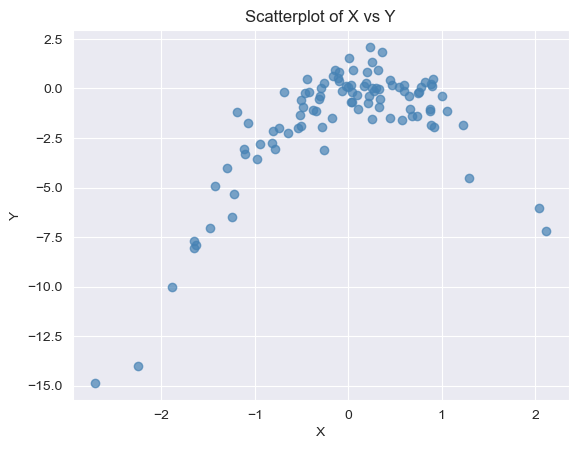

In [63]:
plt.scatter(x, y, color="steelblue", alpha=0.7)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatterplot of X vs Y")
plt.show()

The relationship appears to be roughly quadratic. Y increases when x is less than 0 and decreases when x is greater than 0.

#### (8c) Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:

i. Y= β0 + β1X + ϵ

ii. Y= β0 + β1X + β2X2 + ϵ

iii. Y= β0 + β1X + β2X2 + β3X3 + ϵ

iv. Y= β0 + β1X + β2X2 + β3X3 + β4X4 + ϵ.

Note you may find it helpful to use the data.frame() function to create a single data set containing both X and Y.

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score

loo = LeaveOneOut()

def loocv_mse(x, y, degree):
    X_poly = np.vander(x, N=degree + 1, increasing=True)
    model = LinearRegression()
    mse = -cross_val_score(model, X_poly, y, cv=loo, scoring='neg_mean_squared_error').mean()
    return mse

errors = {}
for d in range(1, 5):
    mse = loocv_mse(x, y, d)
    errors[d] = mse
    print(f"Degree {d}: {mse:.4f}")

Degree 1: 6.6330
Degree 2: 1.1229
Degree 3: 1.3018
Degree 4: 1.3324


#### (8d) Repeat (c) using another random seed, and report your results. Are your results the same as what you got in (c)? Why?

In [65]:
rng = np.random.default_rng(2)
x2 = rng.normal(size=100)
y2 = x2 - 2 * x2**2 + rng.normal(size=100)

print("Repeat with a new random seed:")
for d in range(1, 5):
    mse = loocv_mse(x2, y2, d)
    print(f"Degree {d}: {mse:.4f}")

Repeat with a new random seed:
Degree 1: 7.5606
Degree 2: 0.9840
Degree 3: 0.9682
Degree 4: 0.9660


No, the results aren't the same but they are similar. The LOOCV starts high then decreases to around 1, depending on the noise of the data

#### (8e) Which of the models in (c) had the smallest LOOCV error? Is this what you expected? Explain your answer.

In [66]:
best_degree = min(errors, key=errors.get)
print(best_degree)

2


We should expect the data to be best with degree 2 because it was originally a quadratic equation

#### (9a) Based on this data set, provide an estimate for the population mean of medv. Call this estimate µ.

In [67]:
mu_hat = boston['medv'].mean()
print(f"{mu_hat:.4f}")

22.5328


#### (9b) Provide an estimate of the standard error of µ. Interpret this result.

In [68]:
std_dev = boston['medv'].std()
n = len(boston)
se_formula = std_dev / np.sqrt(n)
print(f"{se_formula:.4f}")

0.4089


The standard error of mu will vary about +- 0.4089 around the true mean

#### (9c) Now estimate the standard error of µ using the bootstrap. How does this compare to your answer from (b)?

In [69]:
from sklearn.utils import resample

def bootstrap_statistic(data, func, n_bootstrap=1000, seed=None):
    rng = np.random.default_rng(seed)
    stats = []
    for _ in range(n_bootstrap):
        sample = resample(data, replace=True, random_state=rng.integers(0, 1e9))
        stats.append(func(sample))
    return np.array(stats)

boot_means = bootstrap_statistic(boston['medv'], np.mean, n_bootstrap=1000, seed=1)
se_bootstrap_mean = boot_means.std()
print(f"{se_bootstrap_mean:.4f}")

0.4071


The bootstrapped standard error is very close to the actual standard error from the data

#### (9d) Based on your bootstrap estimate from (c), provide a 95 % confidence interval for the mean of medv. Compare it to the results obtained by using Boston['medv'].std() and the two standard error rule (3.9).

In [70]:
ci_lower = mu_hat - 2 * se_bootstrap_mean
ci_upper = mu_hat + 2 * se_bootstrap_mean
print(f"[{ci_lower:.4f}, {ci_upper:.4f}]")


[21.7185, 23.3471]


#### (9e) Based on this data set, provide an estimate, µmed, for the median value of medv in the population.

In [71]:
med_hat = boston['medv'].median()
print(f"{med_hat:.4f}")

21.2000


#### (9f) We now would like to estimate the standard error of µmed. Unfortunately, there is no simple formula for computing the standard error of the median. Instead, estimate the standard error of the median using the bootstrap. Comment on your findings.

In [72]:
boot_medians = bootstrap_statistic(boston['medv'], np.median)
se_bootstrap_median = boot_medians.std()
print(f"{se_bootstrap_median:.4f}")

0.3841


Our bootstrap shows that the median only changes by about +- 0.38 from the true median

#### (9g) Based on this data set, provide an estimate for the tenth percentile of medv in Boston census tracts. Call this quantity µ0.1. (You can use the np.percentile() function.)

In [73]:
p10_hat = np.percentile(boston['medv'], 10)
print(f"{p10_hat:.4f}")

12.7500


#### (9h) se the bootstrap to estimate the standard error of µ0.1. Comment on your findings.

In [74]:
boot_p10 = bootstrap_statistic(boston['medv'], lambda x: np.percentile(x, 10))
se_bootstrap_p10 = boot_p10.std()
print(f"{se_bootstrap_p10:.4f}")

0.5087


Our bootstrap shows that the 10th percentile changes by about +- 0.4891 from the true 10th percentile. So the random sampling we do in bootstrapping affects this more than with the means or medians

#### (9a) Split the data set into a training set and a test set.

In [75]:
from sklearn.preprocessing import StandardScaler

X = college.drop(columns=['Apps'])
y = college['Apps']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=1)

#### (9b) Fit a linear model using least squares on the training set, and report the test error obtained.

In [76]:
from sklearn.metrics import mean_squared_error

ols = LinearRegression()
ols.fit(X_train, y_train)
y_pred_ols = ols.predict(X_test)
mse_ols = mean_squared_error(y_test, y_pred_ols)
print(f"{mse_ols:.2f}")

642753.90


#### (9c) Fit a ridge regression model on the training set, with λ chosen by cross-validation. Report the test error obtained.

In [77]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=10)
ridge_cv.fit(X_train, y_train)
ridge_pred = ridge_cv.predict(X_test)
mse_ridge = mean_squared_error(y_test, ridge_pred)
print(f"{mse_ridge:.2f}, Best λ: {ridge_cv.alpha_:.4f}")

682150.75, Best λ: 11.4976


#### (9d) Fit a lasso model on the training set, with λ chosen by cross-validation. Report the test error obtained, along with the number of non-zero coefficient estimates.

In [78]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(cv=10, max_iter=10000, random_state=1)
lasso_cv.fit(X_train, y_train)
lasso_pred = lasso_cv.predict(X_test)
mse_lasso = mean_squared_error(y_test, lasso_pred)
nonzero = np.sum(lasso_cv.coef_ != 0)
print(f"{mse_lasso:.2f}, Best λ: {lasso_cv.alpha_:.4f}, Nonzero Coefficients: {nonzero}")

663855.62, Best λ: 13.4751, Nonzero Coefficients: 14


#### (10a) Generate a data set with p = 20 features, n = 1,000 observations, and an associated quantitative response vector generated according to the model Y= Xβ + ϵ, where β has some elements that are exactly equal to zero.

In [79]:
rng = np.random.default_rng(1)
n, p = 1000, 20

X = rng.normal(size=(n, p))

s = 6
true_nonzero_idx = rng.choice(p, size=s, replace=False)
beta_true = np.zeros(p)
beta_true[true_nonzero_idx] = rng.normal(loc=0.0, scale=2.0, size=s)

eps = rng.normal(scale=1.0, size=n)
y = X @ beta_true + eps

print(f"non-zero betas {sorted(true_nonzero_idx.tolist())}")
print(f"true betas {beta_true[true_nonzero_idx]}")

non-zero betas [1, 2, 4, 10, 11, 17]
true betas [-3.99064449 -1.35375504  1.91579703 -3.13961836  0.82388039  0.38005911]


#### (10b) Split your data set into a training set containing 100 observations and a test set containing 900 observations.

In [80]:
idx = rng.permutation(n)
train_idx, test_idx = idx[:100], idx[100:]

Xtr, Xte = X[train_idx], X[test_idx]
ytr, yte = y[train_idx], y[test_idx]

def add_intercept(A):
    return np.c_[np.ones(A.shape[0]), A]

def ols_fit_predict_mse(Xtr_sub, ytr, Xte_sub, yte):
    Xtr1 = add_intercept(Xtr_sub)
    Xte1 = add_intercept(Xte_sub)
    beta_hat, *_ = np.linalg.lstsq(Xtr1, ytr, rcond=None)
    yhat_tr = Xtr1 @ beta_hat
    yhat_te = Xte1 @ beta_hat
    tr_mse = np.mean((ytr - yhat_tr) ** 2)
    te_mse = np.mean((yte - yhat_te) ** 2)
    return tr_mse, te_mse, beta_hat

#### (10c) Perform best subset selection on the training set, and plot the training set MSE associated with the best model of each size.

In [85]:
from itertools import combinations

best_by_k = {}
train_mse_curve = []
test_mse_curve  = []
best_subsets    = []

for k in range(1, p + 1):
    best_tr_mse = np.inf
    best_subset = None
    best_te_mse = None

    for cols in combinations(range(p), k):
        Xtr_sub = Xtr[:, cols]
        Xte_sub = Xte[:, cols]
        tr_mse, te_mse, _ = ols_fit_predict_mse(Xtr_sub, ytr, Xte_sub, yte)
        if tr_mse < best_tr_mse:
            best_tr_mse = tr_mse
            best_te_mse = te_mse
            best_subset = cols

    best_by_k[k] = {
        "subset": best_subset,
        "train_mse": best_tr_mse,
        "test_mse": best_te_mse,
    }
    train_mse_curve.append(best_tr_mse)
    test_mse_curve.append(best_te_mse)
    best_subsets.append(best_subset)
    print(f"k={k:2d}  best train MSE={best_tr_mse:8.4f}  test MSE={best_te_mse:8.4f}  subset={best_subset}")

k= 1  best train MSE= 14.8783  test MSE= 17.5070  subset=(11,)
k= 2  best train MSE=  6.4084  test MSE=  7.7792  subset=(4, 11)
k= 3  best train MSE=  3.4423  test MSE=  3.6241  subset=(4, 10, 11)
k= 4  best train MSE=  1.8416  test MSE=  1.8057  subset=(1, 4, 10, 11)
k= 5  best train MSE=  1.1280  test MSE=  1.1782  subset=(1, 2, 4, 10, 11)
k= 6  best train MSE=  0.7746  test MSE=  1.1280  subset=(1, 2, 4, 10, 11, 17)
k= 7  best train MSE=  0.7591  test MSE=  1.1247  subset=(1, 2, 4, 8, 10, 11, 17)
k= 8  best train MSE=  0.7513  test MSE=  1.1353  subset=(1, 2, 4, 8, 10, 11, 16, 17)
k= 9  best train MSE=  0.7453  test MSE=  1.1454  subset=(1, 2, 4, 5, 8, 10, 11, 13, 17)
k=10  best train MSE=  0.7386  test MSE=  1.1560  subset=(1, 2, 4, 5, 8, 10, 11, 13, 14, 17)
k=11  best train MSE=  0.7333  test MSE=  1.1612  subset=(1, 2, 4, 5, 8, 10, 11, 13, 14, 16, 17)
k=12  best train MSE=  0.7301  test MSE=  1.1591  subset=(0, 1, 2, 4, 5, 8, 10, 11, 13, 14, 16, 17)
k=13  best train MSE=  0.7285 

#### (10d) Plot the test set MSE associated with the best model of each size.

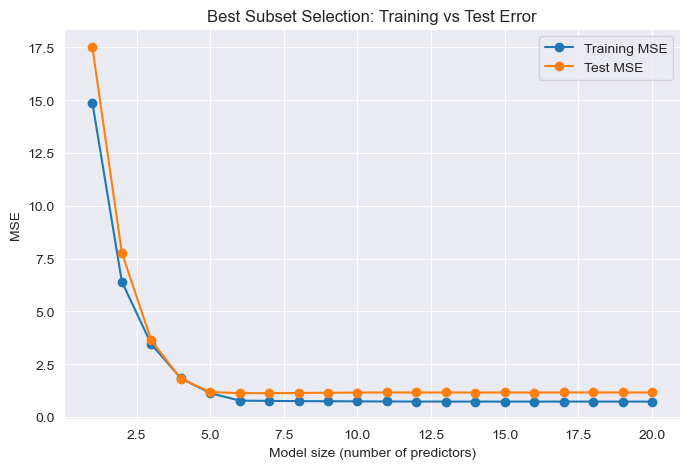

In [86]:
ks = np.arange(1, p + 1)

plt.figure(figsize=(7,4.8))
plt.plot(ks, train_mse_curve, marker='o', label='Training MSE')
plt.plot(ks, test_mse_curve, marker='o', label='Test MSE')
plt.xlabel("Model size (number of predictors)")
plt.ylabel("MSE")
plt.title("Best Subset Selection: Training vs Test Error")
plt.legend()
plt.tight_layout()
plt.show()

#### (10e) For which model size does the test set MSE take on its minimum value? Comment on your results. If it takes on its minimum value for a model containing only an intercept or a model containing all of the features, then play around with the way that you are generating the data in (a) until you come up with a scenario in which the test set MSE is minimized for an intermediate model size.

In [88]:
k_min = int(ks[np.argmin(test_mse_curve)])
subset_min = best_by_k[k_min]["subset"]
min_test_mse = best_by_k[k_min]["test_mse"]
print(f"k={k_min} with subset {subset_min} MSE={min_test_mse:.4f}")

k=7 with subset (1, 2, 4, 8, 10, 11, 17) MSE=1.1247


#### (10f) How does the model at which the test set MSE is minimized compare to the true model used to generate the data? Comment on the coefficient values.

In [84]:
chosen = set(subset_min)
truth  = set(true_nonzero_idx.tolist())
tp = len(chosen & truth)
fp = len(chosen - truth)
fn = len(truth  - chosen)

print(f"nonzero features: {sorted(truth)}")
print(f"features: {sorted(chosen)}")
print(f"TP={tp}, FP={fp}, FN={fn}")

_, _, beta_hat_full = ols_fit_predict_mse(Xtr[:, subset_min], ytr, Xte[:, subset_min], yte)
print("(f) Intercept and coefficients for chosen subset:")
print(beta_hat_full)

nonzero features: [1, 2, 4, 10, 11, 17]
features: [1, 2, 4, 8, 10, 11, 17]
TP=6, FP=1, FN=0
(f) Intercept and coefficients for chosen subset:
[-0.0185154  -1.57610206  0.89978543 -3.09363648 -0.12240889  1.97653198
 -3.95785608  0.60512052]


The model minimized to seven predictors [1,2,4,8,19,11,17]. The true data generating model included six of those [1,2,4,10,11,17]. So our recovery was almost perfect with TP=6, FP=1, FN=0.

This tells us the best-test model successfully found the underlying model creation signal, only grabbing one extra predictor.